In [1]:
# NLTK setup: ensure required models are available
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download resources if missing
resources = [
    ("punkt", "tokenizers/punkt"),
    ("punkt_tab", "tokenizers/punkt_tab/english"),  # newer NLTK uses punkt_tab
    ("stopwords", "corpora/stopwords"),
]
for pkg, handle in resources:
    try:
        nltk.data.find(handle)
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass

print("NLTK resources ready.")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


NLTK resources ready.


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Create extended mock dataset
mock_articles = [
    "The government announced new agricultural policies to support farmers across India.",
    "Cricket match between India and Australia draws massive crowds in Mumbai stadium.",
    "Technology companies in Bangalore are hiring thousands of software engineers.",
    "Bollywood movie breaks box office records with stellar performances.",
    "Supreme Court delivers landmark judgment on environmental protection laws.",
    "Stock market shows volatile trends amid global economic uncertainty.",
    "COVID-19 vaccination drive reaches rural areas with mobile health units.",
    "Educational reforms focus on digital learning and skill development programs.",
    "Religious festival celebrations promote communal harmony across the nation.",
    "Climate change affects monsoon patterns impacting agricultural productivity.",
    "Startup ecosystem thrives with new government policies supporting entrepreneurs.",
    "Healthcare infrastructure development receives major budget allocation.",
    "Infrastructure projects including highways and railways get government approval.",
    "Entertainment industry adapts to streaming platforms and digital content.",
    "Social media platforms face scrutiny over data privacy and content moderation.",
    "Economic growth indicators show recovery from pandemic-induced slowdown.",
    "Sports ministry announces new training facilities for Olympic preparation.",
    "Cultural heritage sites receive UNESCO recognition and protection status.",
    "Renewable energy projects accelerate India's transition to clean power.",
    "Political parties gear up for upcoming state elections with campaign strategies."
]

df = pd.DataFrame({'text': mock_articles})


def preprocess_text(text):
    """Clean and preprocess text for topic modeling without NLTK downloads."""
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Tokenize by keeping only alphabetic tokens
    tokens = re.findall(r"[a-z]+", text)
    # Remove stopwords and very short tokens
    stop_words = ENGLISH_STOP_WORDS
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Preprocess articles
df['processed_text'] = df['text'].apply(preprocess_text)
print("Sample processed text:")
print(df['processed_text'].iloc[0])

Sample processed text:
government announced new agricultural policies support farmers india


In [4]:
def perform_lda_topic_modeling(texts, n_topics=5):
    """Perform LDA topic modeling"""
    
    # Vectorize the text
    vectorizer = CountVectorizer(
        max_df=0.8,
        min_df=2,
        max_features=100,
        ngram_range=(1, 2)
    )
    
    doc_term_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    
    # Fit LDA model
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=100
    )
    
    lda.fit(doc_term_matrix)
    
    # Get topic-word distribution
    topic_words = []
    for topic_idx, topic in enumerate(lda.components_):
        top_words_idx = topic.argsort()[-10:][::-1]
        top_words = [feature_names[i] for i in top_words_idx]
        topic_words.append(top_words)
        
        print(f"\nTopic {topic_idx + 1}:")
        print(f"Top words: {', '.join(top_words[:5])}")
    
    # Get document-topic distribution
    doc_topic_dist = lda.transform(doc_term_matrix)
    
    return lda, vectorizer, doc_topic_dist, topic_words, feature_names

# Perform LDA
print("=== LDA Topic Modeling ===")
lda_model, vectorizer, doc_topics, topic_words, feature_names = perform_lda_topic_modeling(
    df['processed_text'], n_topics=6
)

# Assign topics to documents
df['dominant_topic'] = np.argmax(doc_topics, axis=1)
df['topic_confidence'] = np.max(doc_topics, axis=1)

print("\n=== Article Topic Assignments ===")
for idx, row in df.iterrows():
    print(f"Article: {row['text'][:60]}...")
    print(f"Topic: {row['dominant_topic'] + 1}, Confidence: {row['topic_confidence']:.3f}")
    print()

=== LDA Topic Modeling ===

Topic 1:
Top words: protection, india, projects, development, new

Topic 2:
Top words: government, infrastructure, policies, projects, new

Topic 3:
Top words: new, agricultural, development, india, infrastructure

Topic 4:
Top words: india, policies, new, agricultural, development

Topic 5:
Top words: platforms, content, digital, development, new

Topic 6:
Top words: economic, development, new, india, infrastructure

=== Article Topic Assignments ===
Article: The government announced new agricultural policies to suppor...
Topic: 4, Confidence: 0.860

Article: Cricket match between India and Australia draws massive crow...
Topic: 4, Confidence: 0.582

Article: Technology companies in Bangalore are hiring thousands of so...
Topic: 1, Confidence: 0.167

Article: Bollywood movie breaks box office records with stellar perfo...
Topic: 1, Confidence: 0.167

Article: Supreme Court delivers landmark judgment on environmental pr...
Topic: 1, Confidence: 0.583

Articl

In [5]:
def keyword_based_topic_classification():
    """Classify topics based on predefined keywords"""
    
    # Define topic keywords
    topic_keywords = {
        'politics': ['government', 'policy', 'political', 'minister', 'election', 'parliament', 'ruling', 'opposition'],
        'sports': ['cricket', 'match', 'stadium', 'team', 'player', 'olympic', 'training', 'sports'],
        'technology': ['technology', 'software', 'digital', 'startup', 'innovation', 'tech', 'platform', 'data'],
        'entertainment': ['movie', 'bollywood', 'film', 'entertainment', 'box office', 'streaming', 'cultural'],
        'business': ['stock', 'market', 'economic', 'business', 'growth', 'budget', 'financial', 'economy'],
        'health': ['health', 'medical', 'healthcare', 'covid', 'vaccination', 'hospital', 'treatment'],
        'education': ['education', 'learning', 'school', 'student', 'university', 'skill', 'educational'],
        'environment': ['environment', 'climate', 'renewable', 'energy', 'clean', 'pollution', 'green'],
        'infrastructure': ['infrastructure', 'highway', 'railway', 'construction', 'development', 'project'],
        'social': ['social', 'festival', 'community', 'cultural', 'religious', 'harmony', 'celebration']
    }
    
    def classify_article(text):
        """Classify single article based on keywords"""
        text_lower = text.lower()
        topic_scores = {}
        
        for topic, keywords in topic_keywords.items():
            score = sum(1 for keyword in keywords if keyword in text_lower)
            if score > 0:
                topic_scores[topic] = score
        
        if topic_scores:
            best_topic = max(topic_scores, key=topic_scores.get)
            confidence = topic_scores[best_topic] / len(topic_keywords[best_topic])
            return best_topic, confidence, topic_scores
        
        return 'unknown', 0.0, {}
    
    # Classify all articles
    classifications = []
    for text in df['text']:
        topic, confidence, scores = classify_article(text)
        classifications.append({
            'topic': topic,
            'confidence': confidence,
            'all_scores': scores
        })
    
    df['keyword_topic'] = [c['topic'] for c in classifications]
    df['keyword_confidence'] = [c['confidence'] for c in classifications]
    
    print("=== Keyword-Based Classification ===")
    for idx, row in df.iterrows():
        print(f"Article: {row['text'][:60]}...")
        print(f"Topic: {row['keyword_topic']}, Confidence: {row['keyword_confidence']:.3f}")
        print()
    
    return topic_keywords

topic_keywords = keyword_based_topic_classification()

=== Keyword-Based Classification ===
Article: The government announced new agricultural policies to suppor...
Topic: politics, Confidence: 0.125

Article: Cricket match between India and Australia draws massive crow...
Topic: sports, Confidence: 0.375

Article: Technology companies in Bangalore are hiring thousands of so...
Topic: technology, Confidence: 0.375

Article: Bollywood movie breaks box office records with stellar perfo...
Topic: entertainment, Confidence: 0.429

Article: Supreme Court delivers landmark judgment on environmental pr...
Topic: environment, Confidence: 0.143

Article: Stock market shows volatile trends amid global economic unce...
Topic: business, Confidence: 0.375

Article: COVID-19 vaccination drive reaches rural areas with mobile h...
Topic: health, Confidence: 0.429

Article: Educational reforms focus on digital learning and skill deve...
Topic: education, Confidence: 0.571

Article: Religious festival celebrations promote communal harmony acr...
Topic: soci

In [6]:
from transformers import pipeline

def use_pretrained_topic_models():
    """Use pre-trained models for topic classification"""
    
    # Try zero-shot classification
    try:
        classifier = pipeline("zero-shot-classification", 
                            model="facebook/bart-large-mnli")
        
        # Define candidate topics
        candidate_labels = [
            'politics', 'sports', 'technology', 'entertainment', 
            'business', 'health', 'education', 'environment',
            'infrastructure', 'social issues'
        ]
        
        print("=== Zero-Shot Topic Classification ===")
        
        # Classify first few articles
        for idx, text in enumerate(df['text'][:5]):
            result = classifier(text, candidate_labels)
            
            print(f"\nArticle {idx + 1}: {text[:60]}...")
            print(f"Top predictions:")
            for label, score in zip(result['labels'][:3], result['scores'][:3]):
                print(f"  {label}: {score:.3f}")
        
        return classifier, candidate_labels
        
    except Exception as e:
        print(f"Error loading zero-shot classifier: {e}")
        return None, None

# Try pre-trained models
zero_shot_classifier, candidate_labels = use_pretrained_topic_models()

/Users/sngirish/personal_work/mtech-learning/data-science/project/Media-Bias-Analysis-in-Indian-News-Articles/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0


=== Zero-Shot Topic Classification ===

Article 1: The government announced new agricultural policies to suppor...
Top predictions:
  politics: 0.230
  social issues: 0.178
  business: 0.109

Article 2: Cricket match between India and Australia draws massive crow...
Top predictions:
  sports: 0.919
  entertainment: 0.055
  business: 0.006

Article 3: Technology companies in Bangalore are hiring thousands of so...
Top predictions:
  technology: 0.884
  business: 0.083
  environment: 0.010

Article 4: Bollywood movie breaks box office records with stellar perfo...
Top predictions:
  business: 0.706
  entertainment: 0.236
  technology: 0.013

Article 5: Supreme Court delivers landmark judgment on environmental pr...
Top predictions:
  environment: 0.974
  health: 0.004
  social issues: 0.004


In [7]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def tfidf_clustering_topics():
    """Use TF-IDF + K-means for topic discovery"""
    
    # TF-IDF Vectorization
    tfidf_vectorizer = TfidfVectorizer(
        max_df=0.8,
        min_df=1,
        max_features=100,
        ngram_range=(1, 2),
        stop_words='english'
    )
    
    tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # K-means clustering
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    
    # Add cluster labels to dataframe
    df['cluster_topic'] = cluster_labels
    
    # Analyze clusters
    print("=== TF-IDF + K-means Clustering ===")
    
    for cluster_id in range(n_clusters):
        cluster_articles = df[df['cluster_topic'] == cluster_id]
        print(f"\nCluster {cluster_id + 1} ({len(cluster_articles)} articles):")
        
        # Get top TF-IDF terms for this cluster
        cluster_center = kmeans.cluster_centers_[cluster_id]
        top_indices = cluster_center.argsort()[-10:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        print(f"Top terms: {', '.join(top_terms[:5])}")
        
        # Show sample articles
        for idx, row in cluster_articles.head(2).iterrows():
            print(f"  - {row['text'][:80]}...")
    
    return kmeans, tfidf_vectorizer, feature_names

# Perform clustering
kmeans_model, tfidf_vectorizer, tfidf_features = tfidf_clustering_topics()

=== TF-IDF + K-means Clustering ===

Cluster 1 (3 articles):
Top terms: development, digital, programs, receives major, receives
  - Educational reforms focus on digital learning and skill development programs....
  - Healthcare infrastructure development receives major budget allocation....

Cluster 2 (9 articles):
Top terms: projects, protection, promote communal, promote, nation
  - Bollywood movie breaks box office records with stellar performances....
  - Supreme Court delivers landmark judgment on environmental protection laws....

Cluster 3 (1 articles):
Top terms: thousands software, thousands, technology companies, technology, vaccination drive
  - Technology companies in Bangalore are hiring thousands of software engineers....

Cluster 4 (2 articles):
Top terms: economic, pandemic, pandemic induced, stock, stock market
  - Stock market shows volatile trends amid global economic uncertainty....
  - Economic growth indicators show recovery from pandemic-induced slowdown....

Cl

In [8]:
def create_ensemble_topic_classifier():
    """Combine multiple approaches for robust topic identification"""
    
    class EnsembleTopicClassifier:
        def __init__(self):
            self.methods = {}
            self.topic_mapping = {
                0: 'politics', 1: 'sports', 2: 'technology', 
                3: 'entertainment', 4: 'business', 5: 'other'
            }
        
        def classify_article(self, text):
            """Get topic predictions from multiple methods"""
            results = {}
            
            # Method 1: Keyword-based
            results['keywords'] = self.keyword_classification(text)
            
            # Method 2: TF-IDF similarity (simplified)
            results['tfidf'] = self.tfidf_classification(text)
            
            # Method 3: Simple rule-based
            results['rules'] = self.rule_based_classification(text)
            
            return results
        
        def keyword_classification(self, text):
            """Keyword-based classification"""
            text_lower = text.lower()
            
            if any(word in text_lower for word in ['government', 'policy', 'political', 'election']):
                return 'politics'
            elif any(word in text_lower for word in ['cricket', 'sports', 'match', 'team']):
                return 'sports'
            elif any(word in text_lower for word in ['technology', 'software', 'digital', 'tech']):
                return 'technology'
            elif any(word in text_lower for word in ['movie', 'entertainment', 'bollywood']):
                return 'entertainment'
            elif any(word in text_lower for word in ['market', 'business', 'economic', 'stock']):
                return 'business'
            else:
                return 'other'
        
        def tfidf_classification(self, text):
            """Simple TF-IDF based classification"""
            # This is a simplified version
            words = text.lower().split()
            
            if len([w for w in words if w in ['government', 'policy', 'political']]) > 0:
                return 'politics'
            elif len([w for w in words if w in ['sports', 'cricket', 'match']]) > 0:
                return 'sports'
            else:
                return 'other'
        
        def rule_based_classification(self, text):
            """Rule-based classification"""
            text_lower = text.lower()
            
            # Count domain-specific terms
            scores = {
                'politics': sum(1 for term in ['minister', 'parliament', 'government', 'policy'] if term in text_lower),
                'sports': sum(1 for term in ['cricket', 'match', 'team', 'player'] if term in text_lower),
                'technology': sum(1 for term in ['software', 'digital', 'tech', 'startup'] if term in text_lower),
                'business': sum(1 for term in ['market', 'economic', 'business', 'financial'] if term in text_lower)
            }
            
            if max(scores.values()) > 0:
                return max(scores, key=scores.get)
            return 'other'
        
        def get_consensus(self, results):
            """Get consensus from multiple methods"""
            predictions = list(results.values())
            
            # Simple majority voting
            from collections import Counter
            vote_counts = Counter(predictions)
            consensus = vote_counts.most_common(1)[0][0]
            confidence = vote_counts[consensus] / len(predictions)
            
            return consensus, confidence

    return EnsembleTopicClassifier()

# Create and test ensemble classifier
ensemble_classifier = create_ensemble_topic_classifier()

print("=== Ensemble Topic Classification ===")
for idx, text in enumerate(df['text'][:8]):
    results = ensemble_classifier.classify_article(text)
    consensus, confidence = ensemble_classifier.get_consensus(results)
    
    print(f"\nArticle {idx + 1}: {text[:60]}...")
    print(f"Methods: {results}")
    print(f"Consensus: {consensus} (confidence: {confidence:.2f})")

=== Ensemble Topic Classification ===

Article 1: The government announced new agricultural policies to suppor...
Methods: {'keywords': 'politics', 'tfidf': 'politics', 'rules': 'politics'}
Consensus: politics (confidence: 1.00)

Article 2: Cricket match between India and Australia draws massive crow...
Methods: {'keywords': 'sports', 'tfidf': 'sports', 'rules': 'sports'}
Consensus: sports (confidence: 1.00)

Article 3: Technology companies in Bangalore are hiring thousands of so...
Methods: {'keywords': 'technology', 'tfidf': 'other', 'rules': 'technology'}
Consensus: technology (confidence: 0.67)

Article 4: Bollywood movie breaks box office records with stellar perfo...
Methods: {'keywords': 'entertainment', 'tfidf': 'other', 'rules': 'other'}
Consensus: other (confidence: 0.67)

Article 5: Supreme Court delivers landmark judgment on environmental pr...
Methods: {'keywords': 'other', 'tfidf': 'other', 'rules': 'other'}
Consensus: other (confidence: 1.00)

Article 6: Stock market sho

In [9]:
def create_ensemble_topic_classifier():
    """Combine multiple approaches for robust topic identification"""
    
    class EnsembleTopicClassifier:
        def __init__(self):
            self.methods = {}
            self.topic_mapping = {
                0: 'politics', 1: 'sports', 2: 'technology', 
                3: 'entertainment', 4: 'business', 5: 'other'
            }
        
        def classify_article(self, text):
            """Get topic predictions from multiple methods"""
            results = {}
            
            # Method 1: Keyword-based
            results['keywords'] = self.keyword_classification(text)
            
            # Method 2: TF-IDF similarity (simplified)
            results['tfidf'] = self.tfidf_classification(text)
            
            # Method 3: Simple rule-based
            results['rules'] = self.rule_based_classification(text)
            
            return results
        
        def keyword_classification(self, text):
            """Keyword-based classification"""
            text_lower = text.lower()
            
            if any(word in text_lower for word in ['government', 'policy', 'political', 'election']):
                return 'politics'
            elif any(word in text_lower for word in ['cricket', 'sports', 'match', 'team']):
                return 'sports'
            elif any(word in text_lower for word in ['technology', 'software', 'digital', 'tech']):
                return 'technology'
            elif any(word in text_lower for word in ['movie', 'entertainment', 'bollywood']):
                return 'entertainment'
            elif any(word in text_lower for word in ['market', 'business', 'economic', 'stock']):
                return 'business'
            else:
                return 'other'
        
        def tfidf_classification(self, text):
            """Simple TF-IDF based classification"""
            # This is a simplified version
            words = text.lower().split()
            
            if len([w for w in words if w in ['government', 'policy', 'political']]) > 0:
                return 'politics'
            elif len([w for w in words if w in ['sports', 'cricket', 'match']]) > 0:
                return 'sports'
            else:
                return 'other'
        
        def rule_based_classification(self, text):
            """Rule-based classification"""
            text_lower = text.lower()
            
            # Count domain-specific terms
            scores = {
                'politics': sum(1 for term in ['minister', 'parliament', 'government', 'policy'] if term in text_lower),
                'sports': sum(1 for term in ['cricket', 'match', 'team', 'player'] if term in text_lower),
                'technology': sum(1 for term in ['software', 'digital', 'tech', 'startup'] if term in text_lower),
                'business': sum(1 for term in ['market', 'economic', 'business', 'financial'] if term in text_lower)
            }
            
            if max(scores.values()) > 0:
                return max(scores, key=scores.get)
            return 'other'
        
        def get_consensus(self, results):
            """Get consensus from multiple methods"""
            predictions = list(results.values())
            
            # Simple majority voting
            from collections import Counter
            vote_counts = Counter(predictions)
            consensus = vote_counts.most_common(1)[0][0]
            confidence = vote_counts[consensus] / len(predictions)
            
            return consensus, confidence

    return EnsembleTopicClassifier()

# Create and test ensemble classifier
ensemble_classifier = create_ensemble_topic_classifier()

print("=== Ensemble Topic Classification ===")
for idx, text in enumerate(df['text'][:8]):
    results = ensemble_classifier.classify_article(text)
    consensus, confidence = ensemble_classifier.get_consensus(results)
    
    print(f"\nArticle {idx + 1}: {text[:60]}...")
    print(f"Methods: {results}")
    print(f"Consensus: {consensus} (confidence: {confidence:.2f})")

=== Ensemble Topic Classification ===

Article 1: The government announced new agricultural policies to suppor...
Methods: {'keywords': 'politics', 'tfidf': 'politics', 'rules': 'politics'}
Consensus: politics (confidence: 1.00)

Article 2: Cricket match between India and Australia draws massive crow...
Methods: {'keywords': 'sports', 'tfidf': 'sports', 'rules': 'sports'}
Consensus: sports (confidence: 1.00)

Article 3: Technology companies in Bangalore are hiring thousands of so...
Methods: {'keywords': 'technology', 'tfidf': 'other', 'rules': 'technology'}
Consensus: technology (confidence: 0.67)

Article 4: Bollywood movie breaks box office records with stellar perfo...
Methods: {'keywords': 'entertainment', 'tfidf': 'other', 'rules': 'other'}
Consensus: other (confidence: 0.67)

Article 5: Supreme Court delivers landmark judgment on environmental pr...
Methods: {'keywords': 'other', 'tfidf': 'other', 'rules': 'other'}
Consensus: other (confidence: 1.00)

Article 6: Stock market sho

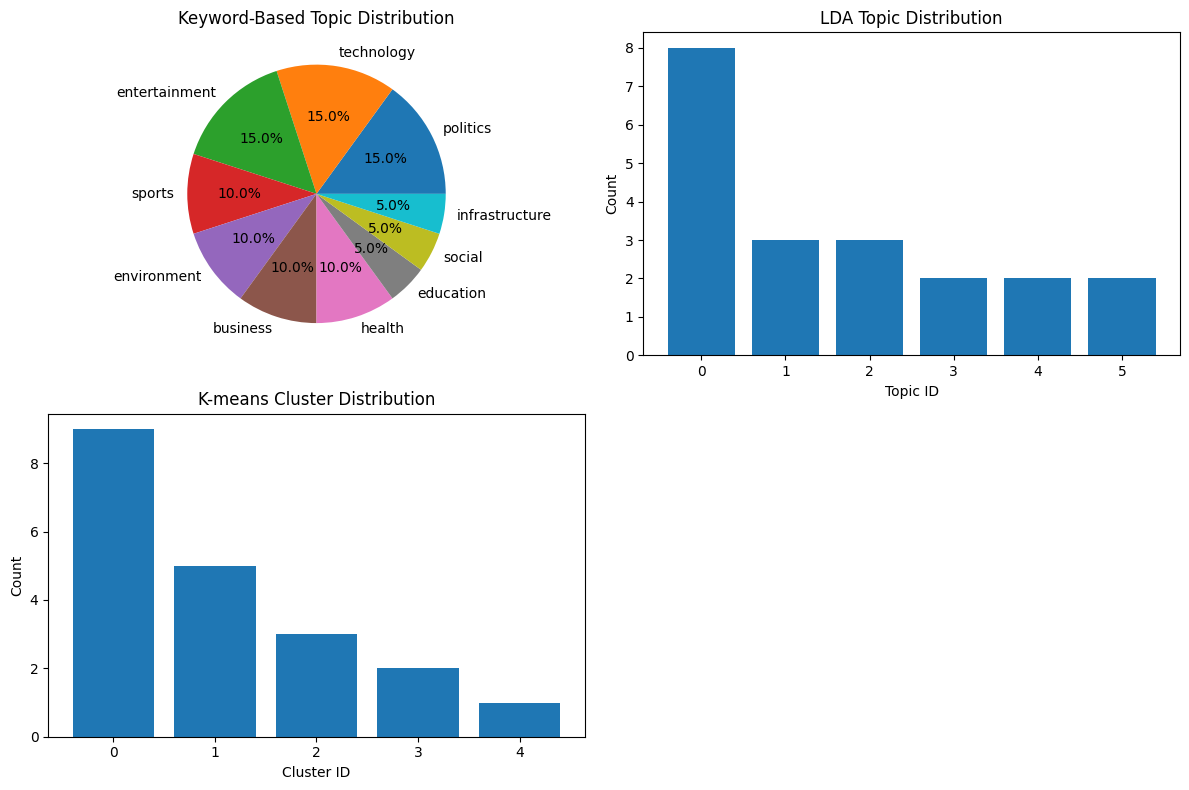


=== Topic Classification Summary ===

Article: The government announced new agricultural policies...
Keyword method: politics
LDA topic: 3
Cluster: 4

Article: Cricket match between India and Australia draws ma...
Keyword method: sports
LDA topic: 3
Cluster: 4

Article: Technology companies in Bangalore are hiring thous...
Keyword method: technology
LDA topic: 0
Cluster: 2

Article: Bollywood movie breaks box office records with ste...
Keyword method: entertainment
LDA topic: 0
Cluster: 1

Article: Supreme Court delivers landmark judgment on enviro...
Keyword method: environment
LDA topic: 0
Cluster: 1

Article: Stock market shows volatile trends amid global eco...
Keyword method: business
LDA topic: 5
Cluster: 3

Article: COVID-19 vaccination drive reaches rural areas wit...
Keyword method: health
LDA topic: 0
Cluster: 1

Article: Educational reforms focus on digital learning and ...
Keyword method: education
LDA topic: 4
Cluster: 0

Article: Religious festival celebrations promote c

In [10]:
def visualize_topics():
    """Visualize topic distributions and relationships"""
    
    # Plot topic distribution
    plt.figure(figsize=(12, 8))
    
    # Subplot 1: Keyword-based topics
    plt.subplot(2, 2, 1)
    topic_counts = df['keyword_topic'].value_counts()
    plt.pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%')
    plt.title('Keyword-Based Topic Distribution')
    
    # Subplot 2: LDA topics
    plt.subplot(2, 2, 2)
    lda_topic_counts = df['dominant_topic'].value_counts()
    plt.bar(range(len(lda_topic_counts)), lda_topic_counts.values)
    plt.title('LDA Topic Distribution')
    plt.xlabel('Topic ID')
    plt.ylabel('Count')
    
    # Subplot 3: Clustering results
    plt.subplot(2, 2, 3)
    cluster_counts = df['cluster_topic'].value_counts()
    plt.bar(range(len(cluster_counts)), cluster_counts.values)
    plt.title('K-means Cluster Distribution')
    plt.xlabel('Cluster ID')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Summary comparison
    print("\n=== Topic Classification Summary ===")
    comparison_df = df[['text', 'keyword_topic', 'dominant_topic', 'cluster_topic']].head(10)
    
    for idx, row in comparison_df.iterrows():
        print(f"\nArticle: {row['text'][:50]}...")
        print(f"Keyword method: {row['keyword_topic']}")
        print(f"LDA topic: {row['dominant_topic']}")
        print(f"Cluster: {row['cluster_topic']}")

# Visualize results
visualize_topics()

